# 03 — Exploração Visual | Contratos por Lugar e Produto
**Mottu | Time de Previsão de Demanda**  
Análise exploratória de contratos criados separados por tipo de negócio (Aluguel / Minha Mottu/Conquiste) e tipo de moto.

**Métricas disponíveis:**
- `contratos_novos` — apenas primeiras locações (`primeira_locacaoId`) ✅ métrica principal

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
COR_MOTTU   = '#FF6B00'
COR_VENDA   = '#FF6B00'
COR_ALUGUEL = '#1A73E8'

print('✅ Imports OK')

✅ Imports OK


In [4]:
# ── Carregar CSV ──────────────────────────────────────────────
df = pd.read_csv('data/raw/contratos_por_lugar_produto.csv', parse_dates=['ano_mes'])

# tipo_negocio e tipo_moto já vêm classificados do SQL
print(f'Shape: {df.shape}')
print(f'Período: {df.ano_mes.min().strftime("%b/%Y")} → {df.ano_mes.max().strftime("%b/%Y")}')
print(f'Lugares: {df.lugar.nunique()}')
print(f'\nDistribuição tipo_negocio x tipo_moto (contratos_novos):')
print(df.groupby(['tipo_negocio','tipo_moto'])['contratos_novos'].sum().to_string())
df.head()

Shape: (14676, 5)
Período: Jan/2025 → Mar/2026
Lugares: 468

Distribuição tipo_negocio x tipo_moto (contratos_novos):
tipo_negocio           tipo_moto
Aluguel / Minha Mottu  Nova          15372
                       Outros         3460
                       Semi-nova      9347
                       Usada         30320
Conquiste              Nova         103615
                       Semi-nova     31919
                       Usada         41177


,ano_mes,lugar,contratos_novos,tipo_negocio,tipo_moto
0,2025-01-01,Mottu Edomex Coacalco,3,Aluguel / Minha Mottu,Usada
1,2025-01-01,Mottu Cancún,2,Aluguel / Minha Mottu,Outros
2,2025-01-01,Mottu Taubaté,6,Conquiste,Nova
3,2025-01-01,Mottu João Pessoa,22,Conquiste,Semi-nova
4,2025-01-01,Mottu Boa Vista,56,Conquiste,Semi-nova


---
## 1 — Contratos Novos por Mês: Aluguel / Minha Mottu vs Conquiste (Brasil)

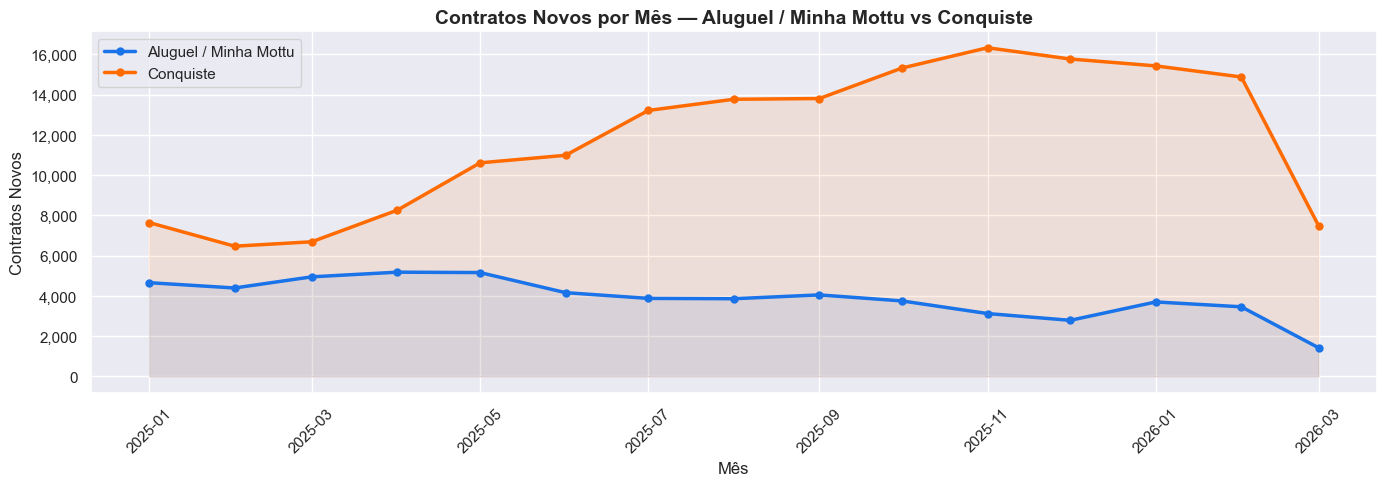

In [5]:
mensal = (
    df.groupby(['ano_mes', 'tipo_negocio'])['contratos_novos']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots()
for tipo, cor in [('Aluguel / Minha Mottu', COR_ALUGUEL), ('Conquiste', COR_VENDA)]:
    d = mensal[mensal['tipo_negocio'] == tipo]
    ax.plot(d['ano_mes'], d['contratos_novos'],
            label=tipo, color=cor, linewidth=2.5, marker='o', markersize=5)
    ax.fill_between(d['ano_mes'], d['contratos_novos'], alpha=0.1, color=cor)

ax.set_title('Contratos Novos por Mês — Aluguel / Minha Mottu vs Conquiste', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Contratos Novos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/raw/grafico_contratos_aluguel_venda.png', dpi=150)
plt.show()

---
## 2 — Contratos Novos por Tipo de Moto (Nova / Semi-nova / Usada)

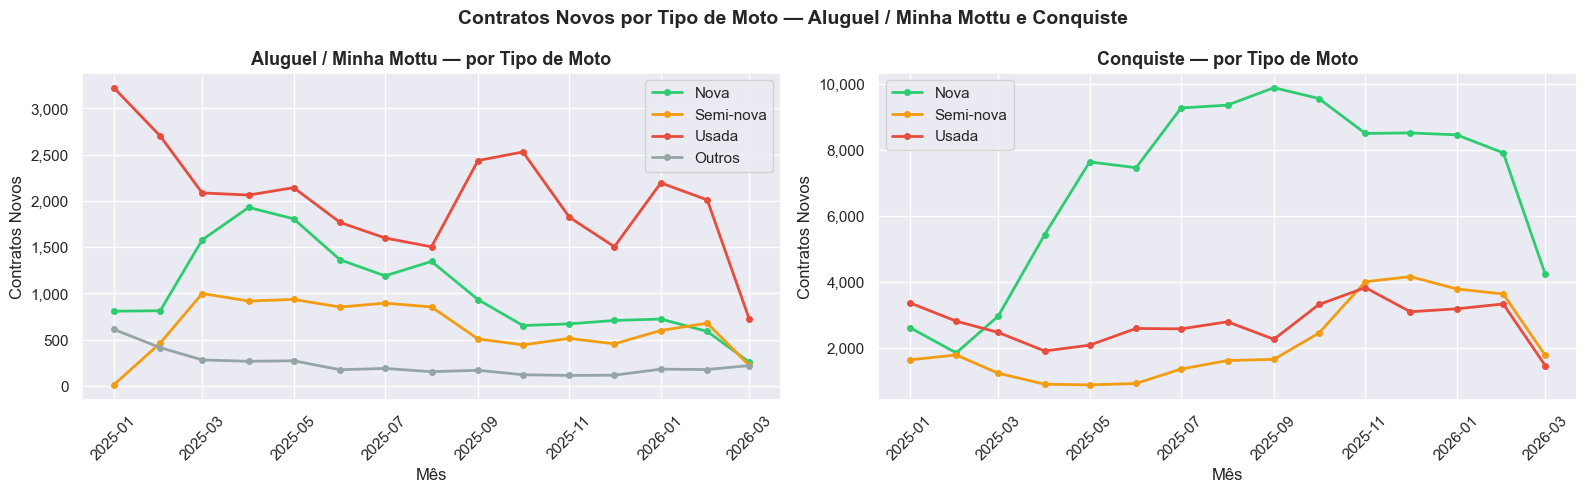

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = {'Nova': '#2ECC71', 'Semi-nova': '#F39C12', 'Usada': '#E74C3C', 'Outros': '#95A5A6'}

for ax, tipo in zip(axes, ['Aluguel / Minha Mottu', 'Conquiste']):
    dados = (
        df[df['tipo_negocio'] == tipo]
        .groupby(['ano_mes', 'tipo_moto'])['contratos_novos']
        .sum()
        .reset_index()
    )
    for moto, cor in palette.items():
        d = dados[dados['tipo_moto'] == moto]
        if not d.empty:
            ax.plot(d['ano_mes'], d['contratos_novos'],
                    label=moto, color=cor, linewidth=2, marker='o', markersize=4)

    ax.set_title(f'{tipo} — por Tipo de Moto', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mês')
    ax.set_ylabel('Contratos Novos')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Contratos Novos por Tipo de Moto — Aluguel / Minha Mottu e Conquiste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/raw/grafico_tipo_moto.png', dpi=150)
plt.show()

---
## 3 — Top 15 Lugares por Contratos Novos (Aluguel / Minha Mottu e Conquiste separados)

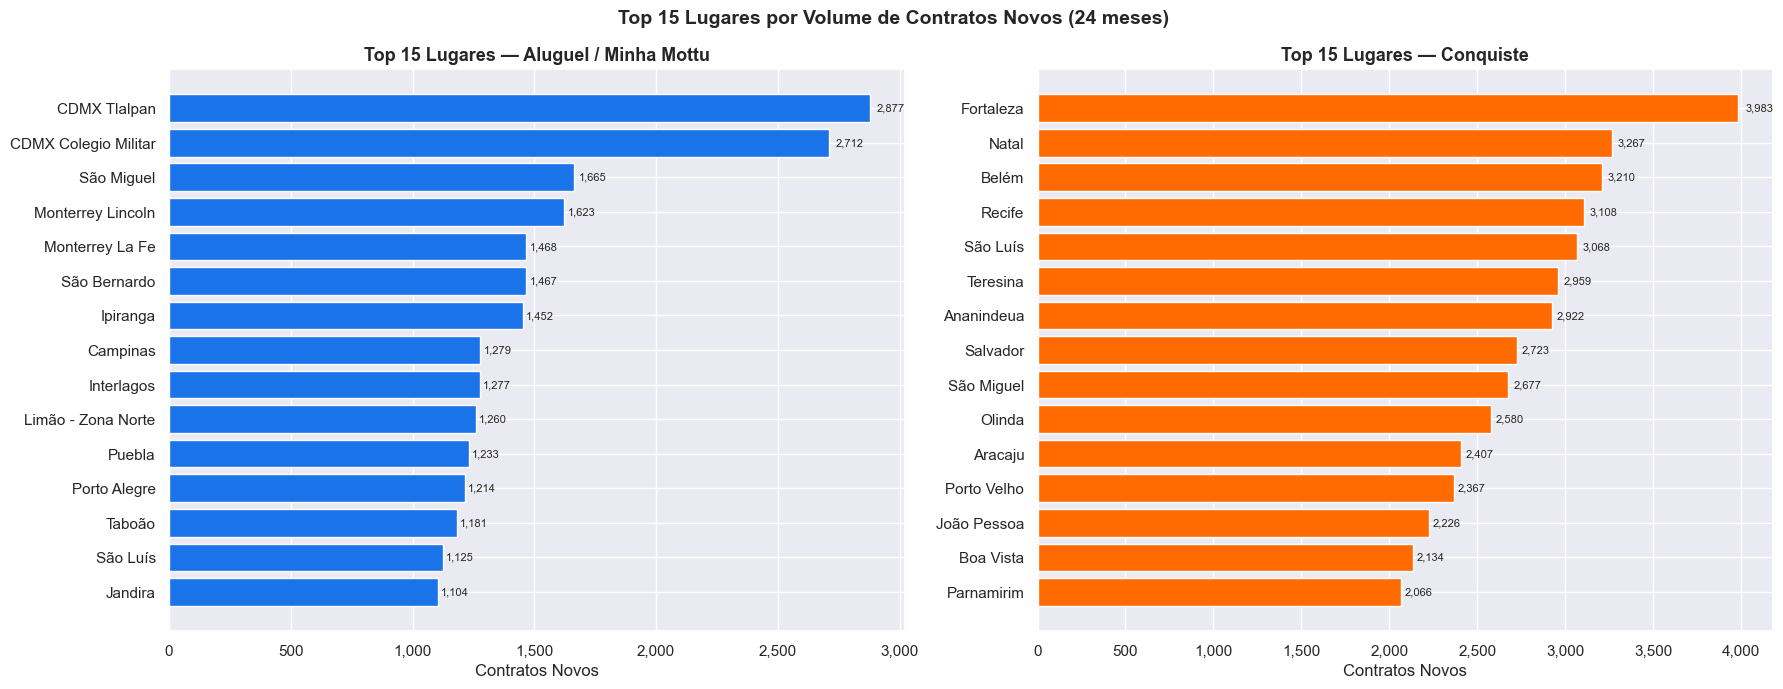

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, tipo, cor in zip(axes, ['Aluguel / Minha Mottu', 'Conquiste'], [COR_ALUGUEL, COR_VENDA]):
    top = (
        df[df['tipo_negocio'] == tipo]
        .groupby('lugar')['contratos_novos']
        .sum()
        .sort_values(ascending=True)
        .tail(15)
    )
    top.index = top.index.str.replace('Mottu ', '', regex=False)

    bars = ax.barh(top.index, top.values, color=cor, edgecolor='white')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + w * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{int(w):,}', va='center', fontsize=8)

    ax.set_title(f'Top 15 Lugares — {tipo}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Contratos Novos')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Top 15 Lugares por Volume de Contratos Novos (24 meses)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/raw/grafico_top_lugares.png', dpi=150)
plt.show()

---
## 4 — Mix de Tipo de Moto por Lugar (Top 10)

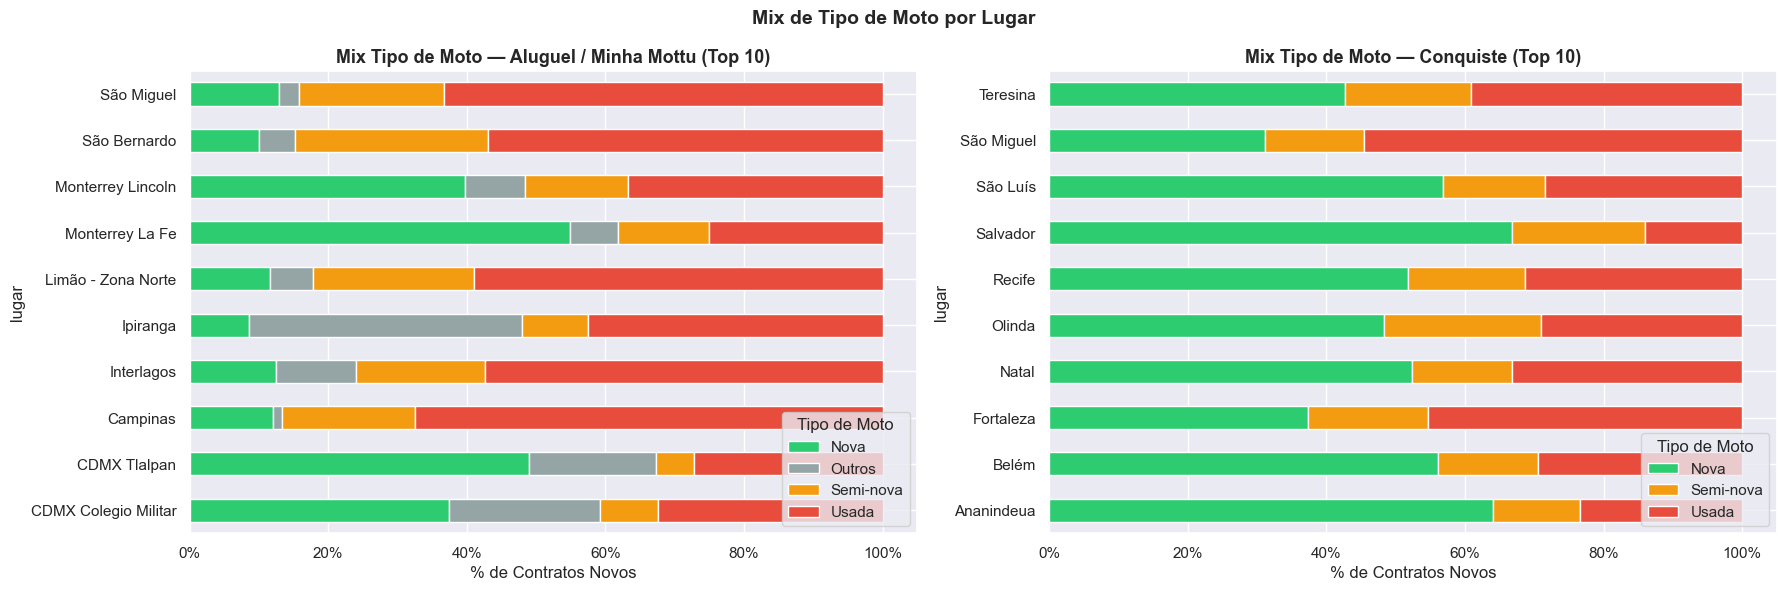

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
palette = {'Nova': '#2ECC71', 'Semi-nova': '#F39C12', 'Usada': '#E74C3C', 'Outros': '#95A5A6'}

for ax, tipo in zip(axes, ['Aluguel / Minha Mottu', 'Conquiste']):
    top10 = (
        df[df['tipo_negocio'] == tipo]
        .groupby('lugar')['contratos_novos']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index
    )
    pivot = (
        df[(df['tipo_negocio'] == tipo) & (df['lugar'].isin(top10))]
        .groupby(['lugar', 'tipo_moto'])['contratos_novos']
        .sum()
        .unstack(fill_value=0)
    )
    pivot.index = pivot.index.str.replace('Mottu ', '', regex=False)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

    pivot_pct.plot(kind='barh', stacked=True, ax=ax,
                  color=[palette.get(c, '#aaa') for c in pivot_pct.columns])

    ax.set_title(f'Mix Tipo de Moto — {tipo} (Top 10)', fontsize=13, fontweight='bold')
    ax.set_xlabel('% de Contratos Novos')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.legend(title='Tipo de Moto', loc='lower right')

plt.suptitle('Mix de Tipo de Moto por Lugar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/raw/grafico_mix_tipo_moto.png', dpi=150)
plt.show()

---
## 5 — Crescimento MoM% — Aluguel / Minha Mottu vs Conquiste

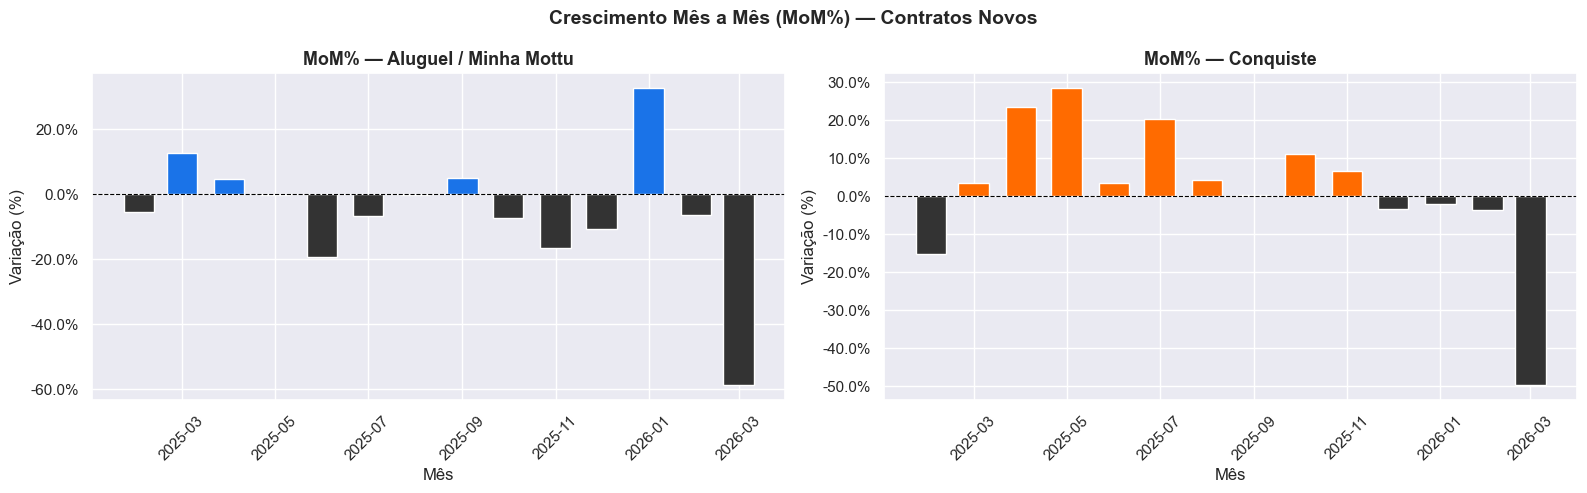

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, tipo, cor in zip(axes, ['Aluguel / Minha Mottu', 'Conquiste'], [COR_ALUGUEL, COR_VENDA]):
    d = (
        mensal[mensal['tipo_negocio'] == tipo]
        .sort_values('ano_mes')
        .copy()
    )
    d['mom_pct'] = d['contratos_novos'].pct_change() * 100
    cores = [cor if v >= 0 else '#333333' for v in d['mom_pct'].fillna(0)]

    ax.bar(d['ano_mes'], d['mom_pct'], color=cores, width=20)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'MoM% — {tipo}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mês')
    ax.set_ylabel('Variação (%)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Crescimento Mês a Mês (MoM%) — Contratos Novos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/raw/grafico_mom_contratos.png', dpi=150)
plt.show()